## **Sentiment Analysis**

I want to approach this through BERT. The `multilingual-sentiment-analysis` model by `tabularisai` seems to be best fit as my dataset contains tagalog and english contents. Although it shows more english-comments/posts, it is necessary to try to take into account the tagalog content.


---
**Setup**

In [41]:
!pip install transformers



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 3070


In [43]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("tabularisai/multilingual-sentiment-analysis")
model = AutoModelForSequenceClassification.from_pretrained("tabularisai/multilingual-sentiment-analysis")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


---
**Run the code**

In [44]:
import numpy as np
import pandas as pd

id2label = model.config.id2label

def get_sentiment(text):
    if not isinstance(text, str):
        text = str(text)

    # Tokenize and move input tensors to GPU
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        scores = outputs.logits[0]
        label_id = int(torch.argmax(scores))
        confidence = float(torch.softmax(scores, dim=0)[label_id])

    return id2label[label_id], confidence



In [45]:
rappler_corpus = pd.read_csv("../data/News/rappler_with_topics.csv")
reddit_corpus = pd.read_csv("../data/Reddit/reddit_with_topics.csv")


In [46]:
reddit_corpus["sentiment_label"], reddit_corpus["sentiment_score"] = zip(
    *reddit_corpus["post_full"].astype(str).apply(get_sentiment)
)

In [47]:
rappler_corpus["sentiment_label"], rappler_corpus["sentiment_score"] = zip(
    *rappler_corpus["cleaned_text"].astype(str).apply(get_sentiment)
)

---
**Sentiment Results**

In [48]:
reddit_corpus["sentiment_label"].value_counts()


sentiment_label
Neutral          8368
Negative         2802
Very Negative    1098
Positive          350
Very Positive     112
Name: count, dtype: int64

In [49]:
rappler_corpus["sentiment_label"].value_counts()


sentiment_label
Neutral          113
Negative           6
Very Positive      2
Name: count, dtype: int64

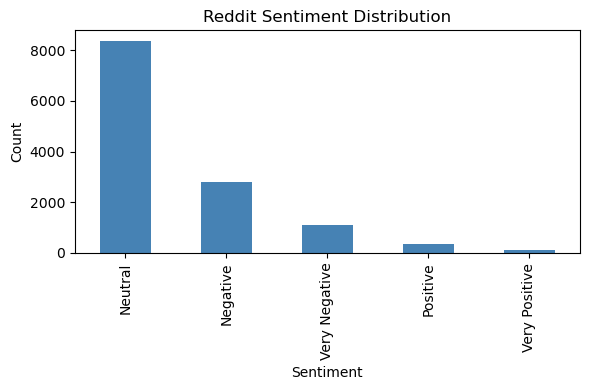

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
reddit_corpus["sentiment_label"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Reddit Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../IEEE/figures/reddit_sentiment_distribution.png", dpi=300)
plt.show()


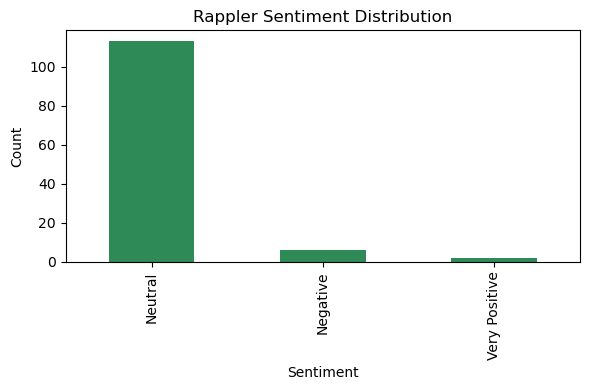

In [51]:
plt.figure(figsize=(6,4))
rappler_corpus["sentiment_label"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Rappler Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../IEEE/figures/rappler_sentiment_distribution.png", dpi=300)
plt.show()


---
**Topic and Sentiment Overlaps**

In [52]:
reddit_cross = pd.crosstab(
    reddit_corpus["dominant_topic"],
    reddit_corpus["sentiment_label"],
    normalize="index"   # percent per topic
)

reddit_cross


sentiment_label,Negative,Neutral,Positive,Very Negative,Very Positive
dominant_topic,,,,,
0,0.251095,0.660730,0.011971,0.075912,0.000292
1,0.402586,0.557735,0.000446,0.039233,0.000000
2,0.150463,0.720833,0.117130,0.010185,0.001389
3,0.055556,0.791910,0.025828,0.074561,0.052144
4,0.210526,0.586667,0.000702,0.201754,0.000351


In [53]:
rappler_cross = pd.crosstab(
    rappler_corpus["dominant_topic"],
    rappler_corpus["sentiment_label"],
    normalize="index"
)

rappler_cross


sentiment_label,Negative,Neutral,Very Positive
dominant_topic,,,
0,0.000000,0.960000,0.040000
1,0.040000,0.960000,0.000000
2,0.066667,0.866667,0.066667
3,0.029412,0.970588,0.000000
4,0.136364,0.863636,0.000000


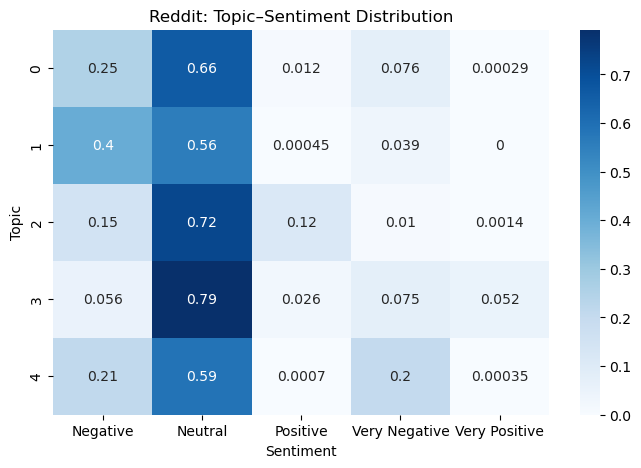

In [54]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(reddit_cross, annot=True, cmap="Blues")
plt.title("Reddit: Topic–Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Topic")
plt.show()


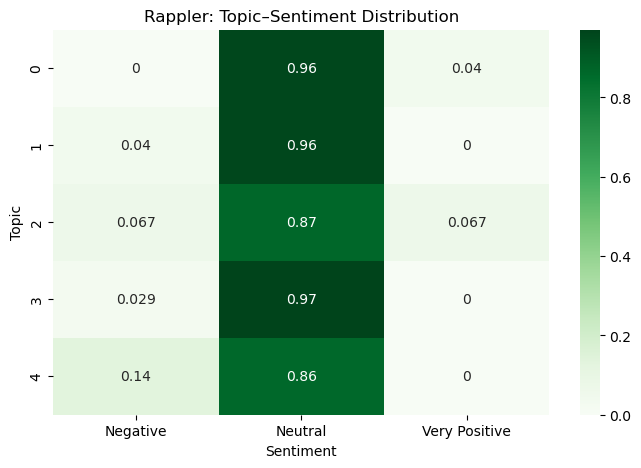

In [55]:
plt.figure(figsize=(8,5))
sns.heatmap(rappler_cross, annot=True, cmap="Greens")
plt.title("Rappler: Topic–Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Topic")
plt.show()
